<a href="https://colab.research.google.com/github/xiyuan1avery/ma2288/blob/main/notebooks/07_train_multistep_mlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q transformers pandas matplotlib

In [2]:
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, TensorDataset

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [3]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
DRIVE_DIRECTORY = Path(
    "/content/drive/MyDrive/ma2288_nextlat"
)

TRAIN_DATA_PATH = (
    DRIVE_DIRECTORY
    / "train_teacher_states.pt"
)

VALIDATION_DATA_PATH = (
    DRIVE_DIRECTORY
    / "validation_teacher_states.pt"
)

ONE_STEP_CHECKPOINT_PATH = (
    DRIVE_DIRECTORY
    / "checkpoints"
    / "one_step_transition_seed42.pt"
)

print("Train data:", TRAIN_DATA_PATH.exists())
print("Validation data:", VALIDATION_DATA_PATH.exists())
print(
    "One-step checkpoint:",
    ONE_STEP_CHECKPOINT_PATH.exists(),
)

Train data: True
Validation data: True
One-step checkpoint: True


In [5]:
train_artifact = torch.load(
    TRAIN_DATA_PATH,
    map_location="cpu",
    weights_only=False,
)

validation_artifact = torch.load(
    VALIDATION_DATA_PATH,
    map_location="cpu",
    weights_only=False,
)

train_token_ids = train_artifact[
    "token_ids"
]

train_hidden_states = train_artifact[
    "hidden_states"
]

validation_token_ids = validation_artifact[
    "token_ids"
]

validation_hidden_states = validation_artifact[
    "hidden_states"
]

print("Train tokens:", train_token_ids.shape)
print("Train hidden:", train_hidden_states.shape)
print(
    "Validation tokens:",
    validation_token_ids.shape,
)
print(
    "Validation hidden:",
    validation_hidden_states.shape,
)

Train tokens: torch.Size([400, 64])
Train hidden: torch.Size([400, 64, 768])
Validation tokens: torch.Size([80, 64])
Validation hidden: torch.Size([80, 64, 768])


In [6]:
ROLLOUT_LENGTH = 8
TRAIN_STRIDE = 4
VALIDATION_STRIDE = 8


def create_window_indices(
    number_of_blocks,
    sequence_length,
    rollout_length,
    stride,
):
    block_indices = []
    start_positions = []

    maximum_start = (
        sequence_length
        - rollout_length
        - 1
    )

    for block_index in range(
        number_of_blocks
    ):
        for start_position in range(
            0,
            maximum_start + 1,
            stride,
        ):
            block_indices.append(
                block_index
            )

            start_positions.append(
                start_position
            )

    return (
        torch.tensor(
            block_indices,
            dtype=torch.long,
        ),
        torch.tensor(
            start_positions,
            dtype=torch.long,
        ),
    )

In [7]:
(
    train_block_indices,
    train_start_positions,
) = create_window_indices(
    number_of_blocks=(
        train_hidden_states.shape[0]
    ),
    sequence_length=(
        train_hidden_states.shape[1]
    ),
    rollout_length=ROLLOUT_LENGTH,
    stride=TRAIN_STRIDE,
)

(
    validation_block_indices,
    validation_start_positions,
) = create_window_indices(
    number_of_blocks=(
        validation_hidden_states.shape[0]
    ),
    sequence_length=(
        validation_hidden_states.shape[1]
    ),
    rollout_length=ROLLOUT_LENGTH,
    stride=VALIDATION_STRIDE,
)

print(
    "Training windows:",
    len(train_block_indices),
)

print(
    "Validation windows:",
    len(validation_block_indices),
)

Training windows: 5600
Validation windows: 560


In [8]:
BATCH_SIZE = 64

train_window_dataset = TensorDataset(
    train_block_indices,
    train_start_positions,
)

validation_window_dataset = TensorDataset(
    validation_block_indices,
    validation_start_positions,
)

train_generator = torch.Generator()
train_generator.manual_seed(SEED)

train_loader = DataLoader(
    train_window_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=train_generator,
    num_workers=0,
)

validation_loader = DataLoader(
    validation_window_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

print("Train batches:", len(train_loader))
print(
    "Validation batches:",
    len(validation_loader),
)

Train batches: 88
Validation batches: 9


In [9]:
from transformers import AutoModelForCausalLM

MODEL_NAME = train_artifact[
    "model_name"
]

language_model = (
    AutoModelForCausalLM
    .from_pretrained(MODEL_NAME)
    .to(device)
)

language_model.eval()

for parameter in language_model.parameters():
    parameter.requires_grad = False

token_embedding = (
    language_model.get_input_embeddings()
)

print("Loaded:", MODEL_NAME)

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  353MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Loaded: distilgpt2


In [10]:
class ResidualTransitionMLP(nn.Module):
    def __init__(
        self,
        hidden_dimension=768,
        bottleneck_dimension=512,
    ):
        super().__init__()

        combined_dimension = (
            hidden_dimension * 2
        )

        self.input_normalization = nn.LayerNorm(
            combined_dimension
        )

        self.network = nn.Sequential(
            nn.Linear(
                combined_dimension,
                bottleneck_dimension,
            ),
            nn.GELU(),
            nn.Linear(
                bottleneck_dimension,
                hidden_dimension,
            ),
        )

    def forward(
        self,
        current_hidden,
        next_token_embedding,
    ):
        combined_input = torch.cat(
            [
                current_hidden,
                next_token_embedding,
            ],
            dim=-1,
        )

        normalized_input = (
            self.input_normalization(
                combined_input
            )
        )

        predicted_change = self.network(
            normalized_input
        )

        return (
            current_hidden
            + predicted_change
        )

In [11]:
one_step_checkpoint = torch.load(
    ONE_STEP_CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False,
)

transition_model = ResidualTransitionMLP(
    hidden_dimension=one_step_checkpoint[
        "hidden_dimension"
    ],
    bottleneck_dimension=one_step_checkpoint[
        "bottleneck_dimension"
    ],
)

transition_model.load_state_dict(
    one_step_checkpoint[
        "model_state_dict"
    ]
)

transition_model = transition_model.to(
    device
)

print(
    "Loaded one-step validation loss:",
    one_step_checkpoint[
        "best_validation_loss"
    ],
)

Loaded one-step validation loss: 0.12297592103954345


In [12]:
def compute_rollout_loss(
    transition_model,
    token_ids,
    hidden_states,
    block_indices,
    start_positions,
):
    block_indices = (
        block_indices.long()
    )

    start_positions = (
        start_positions.long()
    )

    # 初始状态使用真实 h_t
    current_prediction = hidden_states[
        block_indices,
        start_positions,
    ].float().to(device)

    total_loss = 0.0
    step_losses = []

    for step in range(
        1,
        ROLLOUT_LENGTH + 1,
    ):
        token_positions = (
            start_positions + step
        )

        next_token_ids = token_ids[
            block_indices,
            token_positions,
        ].to(device)

        target_hidden = hidden_states[
            block_indices,
            token_positions,
        ].float().to(device)

        with torch.no_grad():
            next_embeddings = (
                token_embedding(
                    next_token_ids
                )
            )

        current_prediction = (
            transition_model(
                current_prediction,
                next_embeddings,
            )
        )

        step_loss = F.smooth_l1_loss(
            current_prediction,
            target_hidden,
            reduction="mean",
        )

        total_loss = (
            total_loss + step_loss
        )

        step_losses.append(
            step_loss.detach()
        )

    mean_loss = (
        total_loss / ROLLOUT_LENGTH
    )

    return mean_loss, step_losses

In [13]:
def evaluate_multistep_model(
    transition_model,
):
    transition_model.eval()

    total_loss = 0.0
    total_windows = 0

    step_loss_sums = torch.zeros(
        ROLLOUT_LENGTH
    )

    with torch.no_grad():
        for (
            block_indices,
            start_positions,
        ) in validation_loader:

            loss, step_losses = (
                compute_rollout_loss(
                    transition_model,
                    validation_token_ids,
                    validation_hidden_states,
                    block_indices,
                    start_positions,
                )
            )

            batch_size = len(
                block_indices
            )

            total_loss += (
                loss.item() * batch_size
            )

            total_windows += batch_size

            for step_index, step_loss in enumerate(
                step_losses
            ):
                step_loss_sums[
                    step_index
                ] += (
                    step_loss.cpu()
                    * batch_size
                )

    return {
        "mean_rollout_loss": (
            total_loss / total_windows
        ),
        "step_losses": (
            step_loss_sums
            / total_windows
        ).tolist(),
    }

In [14]:
LEARNING_RATE = 2e-4
MAX_EPOCHS = 12
PATIENCE = 3

optimizer = torch.optim.AdamW(
    transition_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4,
)

best_validation_loss = float("inf")
best_model_state = None
epochs_without_improvement = 0

training_history = []

In [15]:
for epoch in range(
    1,
    MAX_EPOCHS + 1,
):
    transition_model.train()

    total_train_loss = 0.0
    total_train_windows = 0

    for (
        block_indices,
        start_positions,
    ) in train_loader:

        loss, _ = compute_rollout_loss(
            transition_model,
            train_token_ids,
            train_hidden_states,
            block_indices,
            start_positions,
        )

        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            transition_model.parameters(),
            max_norm=1.0,
        )

        optimizer.step()

        batch_size = len(
            block_indices
        )

        total_train_loss += (
            loss.item() * batch_size
        )

        total_train_windows += (
            batch_size
        )

    mean_train_loss = (
        total_train_loss
        / total_train_windows
    )

    validation_metrics = (
        evaluate_multistep_model(
            transition_model
        )
    )

    validation_loss = (
        validation_metrics[
            "mean_rollout_loss"
        ]
    )

    training_history.append({
        "epoch": epoch,
        "train_rollout_loss": (
            mean_train_loss
        ),
        "validation_rollout_loss": (
            validation_loss
        ),
        "validation_step_1_loss": (
            validation_metrics[
                "step_losses"
            ][0]
        ),
        "validation_step_4_loss": (
            validation_metrics[
                "step_losses"
            ][3]
        ),
        "validation_step_8_loss": (
            validation_metrics[
                "step_losses"
            ][7]
        ),
    })

    print(
        f"Epoch {epoch:02d} | "
        f"train: {mean_train_loss:.6f} | "
        f"validation: "
        f"{validation_loss:.6f} | "
        f"step 1: "
        f"{validation_metrics['step_losses'][0]:.6f} | "
        f"step 4: "
        f"{validation_metrics['step_losses'][3]:.6f} | "
        f"step 8: "
        f"{validation_metrics['step_losses'][7]:.6f}"
    )

    if (
        validation_loss
        < best_validation_loss
    ):
        best_validation_loss = (
            validation_loss
        )

        best_model_state = copy.deepcopy(
            transition_model.state_dict()
        )

        epochs_without_improvement = 0
        print("  New best model.")

    else:
        epochs_without_improvement += 1

        print(
            "  Epochs without improvement:",
            epochs_without_improvement,
        )

    if (
        epochs_without_improvement
        >= PATIENCE
    ):
        print("Early stopping.")
        break

Epoch 01 | train: 0.123514 | validation: 0.136979 | step 1: 0.117626 | step 4: 0.136461 | step 8: 0.153103
  New best model.
Epoch 02 | train: 0.117309 | validation: 0.136880 | step 1: 0.117589 | step 4: 0.136523 | step 8: 0.152953
  New best model.
Epoch 03 | train: 0.115865 | validation: 0.135877 | step 1: 0.117475 | step 4: 0.135033 | step 8: 0.152112
  New best model.
Epoch 04 | train: 0.114018 | validation: 0.135192 | step 1: 0.117393 | step 4: 0.134624 | step 8: 0.150442
  New best model.
Epoch 05 | train: 0.113093 | validation: 0.135476 | step 1: 0.117576 | step 4: 0.135032 | step 8: 0.150485
  Epochs without improvement: 1
Epoch 06 | train: 0.112113 | validation: 0.135520 | step 1: 0.117672 | step 4: 0.135040 | step 8: 0.150707
  Epochs without improvement: 2
Epoch 07 | train: 0.111542 | validation: 0.136131 | step 1: 0.117843 | step 4: 0.135946 | step 8: 0.150555
  Epochs without improvement: 3
Early stopping.


In [16]:
transition_model.load_state_dict(
    best_model_state
)

best_metrics = (
    evaluate_multistep_model(
        transition_model
    )
)

print("Best validation rollout metrics:")
print(best_metrics)

Best validation rollout metrics:
{'mean_rollout_loss': 0.1351916551589966, 'step_losses': [0.11739332973957062, 0.13053400814533234, 0.13283973932266235, 0.1346244364976883, 0.1356291025876999, 0.1360192596912384, 0.14405177533626556, 0.15044157207012177]}


In [17]:
history_df = pd.DataFrame(
    training_history
)

print(
    history_df.to_string(
        index=False
    )
)

 epoch  train_rollout_loss  validation_rollout_loss  validation_step_1_loss  validation_step_4_loss  validation_step_8_loss
     1            0.123514                 0.136979                0.117626                0.136461                0.153103
     2            0.117309                 0.136880                0.117589                0.136523                0.152953
     3            0.115865                 0.135877                0.117475                0.135033                0.152112
     4            0.114018                 0.135192                0.117393                0.134624                0.150442
     5            0.113093                 0.135476                0.117576                0.135032                0.150485
     6            0.112113                 0.135520                0.117672                0.135040                0.150707
     7            0.111542                 0.136131                0.117843                0.135946                0.150555


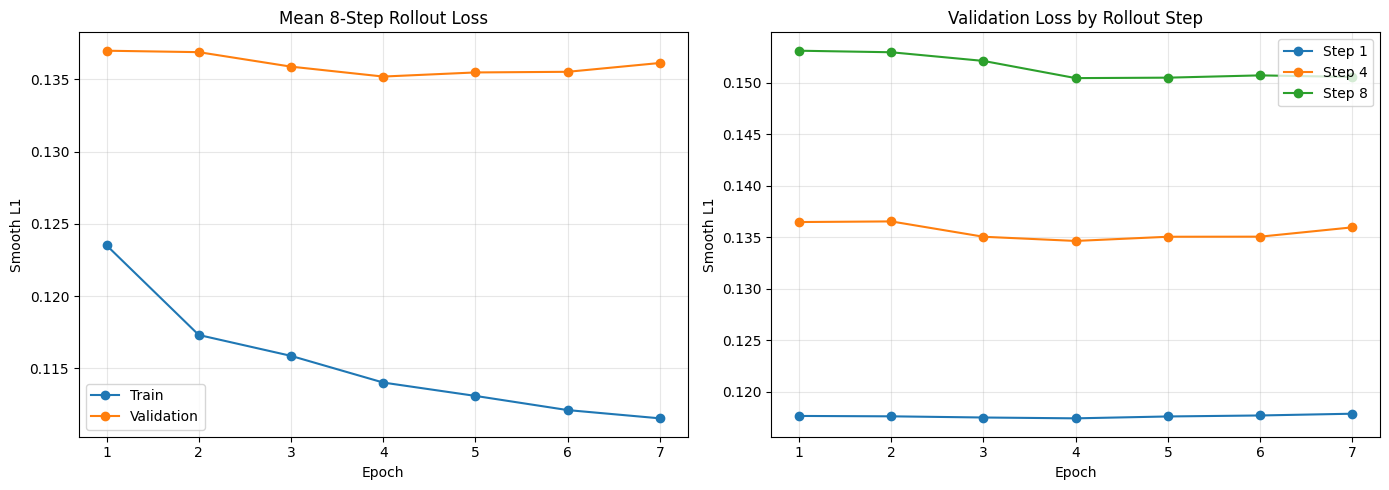

In [18]:
figure, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
)

axes[0].plot(
    history_df["epoch"],
    history_df[
        "train_rollout_loss"
    ],
    marker="o",
    label="Train",
)

axes[0].plot(
    history_df["epoch"],
    history_df[
        "validation_rollout_loss"
    ],
    marker="o",
    label="Validation",
)

axes[0].set_title(
    "Mean 8-Step Rollout Loss"
)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Smooth L1")
axes[0].legend()
axes[0].grid(alpha=0.3)

for column, label in [
    (
        "validation_step_1_loss",
        "Step 1",
    ),
    (
        "validation_step_4_loss",
        "Step 4",
    ),
    (
        "validation_step_8_loss",
        "Step 8",
    ),
]:
    axes[1].plot(
        history_df["epoch"],
        history_df[column],
        marker="o",
        label=label,
    )

axes[1].set_title(
    "Validation Loss by Rollout Step"
)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Smooth L1")
axes[1].legend()
axes[1].grid(alpha=0.3)

figure.tight_layout()
plt.show()

In [19]:
CHECKPOINT_DIRECTORY = (
    DRIVE_DIRECTORY
    / "checkpoints"
)

CHECKPOINT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

MULTISTEP_CHECKPOINT_PATH = (
    CHECKPOINT_DIRECTORY
    / "multistep_transition_seed42.pt"
)

multistep_checkpoint = {
    "model_state_dict": (
        transition_model.state_dict()
    ),
    "model_name": MODEL_NAME,
    "hidden_dimension": 768,
    "bottleneck_dimension": 512,
    "seed": SEED,
    "rollout_length": ROLLOUT_LENGTH,
    "learning_rate": LEARNING_RATE,
    "initial_checkpoint": (
        "one_step_transition_seed42.pt"
    ),
    "best_validation_rollout_loss": (
        best_validation_loss
    ),
    "training_history": (
        training_history
    ),
}

torch.save(
    multistep_checkpoint,
    MULTISTEP_CHECKPOINT_PATH,
)

print(
    "Saved:",
    MULTISTEP_CHECKPOINT_PATH
)

print(
    "Checkpoint exists:",
    MULTISTEP_CHECKPOINT_PATH.exists()
)

Saved: /content/drive/MyDrive/ma2288_nextlat/checkpoints/multistep_transition_seed42.pt
Checkpoint exists: True


In [20]:
RESULT_DIRECTORY = (
    DRIVE_DIRECTORY
    / "results"
)

TABLE_DIRECTORY = (
    RESULT_DIRECTORY
    / "tables"
)

FIGURE_DIRECTORY = (
    RESULT_DIRECTORY
    / "figures"
)

TABLE_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURE_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

history_df.to_csv(
    TABLE_DIRECTORY
    / "multistep_training_history.csv",
    index=False,
)

figure.savefig(
    FIGURE_DIRECTORY
    / "multistep_training_curve.png",
    dpi=200,
    bbox_inches="tight",
)

In [22]:
one_step_reference_model = (
    ResidualTransitionMLP(
        hidden_dimension=768,
        bottleneck_dimension=512,
    )
)

one_step_reference_model.load_state_dict(
    one_step_checkpoint[
        "model_state_dict"
    ]
)

one_step_reference_model = (
    one_step_reference_model.to(device)
)

one_step_metrics = (
    evaluate_multistep_model(
        one_step_reference_model
    )
)

multistep_metrics = (
    evaluate_multistep_model(
        transition_model
    )
)

print("One-step checkpoint:")
print(one_step_metrics)

print("\nMulti-step checkpoint:")
print(multistep_metrics)

improvement_percent = (
    100
    * (
        one_step_metrics[
            "mean_rollout_loss"
        ]
        - multistep_metrics[
            "mean_rollout_loss"
        ]
    )
    / one_step_metrics[
        "mean_rollout_loss"
    ]
)

print(
    "\nValidation rollout loss "
    f"reduction: {improvement_percent:.2f}%"
)

One-step checkpoint:
{'mean_rollout_loss': 0.14927859348910197, 'step_losses': [0.11914174258708954, 0.13521742820739746, 0.14126300811767578, 0.14721153676509857, 0.15047481656074524, 0.15564943850040436, 0.16737885773181915, 0.17789189517498016]}

Multi-step checkpoint:
{'mean_rollout_loss': 0.1351916551589966, 'step_losses': [0.11739332973957062, 0.13053400814533234, 0.13283973932266235, 0.1346244364976883, 0.1356291025876999, 0.1360192596912384, 0.14405177533626556, 0.15044157207012177]}

Validation rollout loss reduction: 9.44%
